In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import BinaryAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives, Precision, Recall, AUC
from tqdm import tqdm
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input  # FIX: Added preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')


All libraries imported successfully!
TensorFlow version: 2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
# Dataset path for Lung Cancer
dataset_path = '/content/drive/MyDrive/Lung Dataset-20260126T115935Z-1-001/Lung Dataset'

# Get class labels from directory
labels = sorted(os.listdir(dataset_path))
print(f'Classes found: {labels}')
print(f'Number of classes: {len(labels)}')

# Image configuration
image_size = 224
print(f'Image size: {image_size}x{image_size}')

Classes found: ['Benign', 'Malignant', 'Normal']
Number of classes: 3
Image size: 224x224


In [4]:
# Load all images
X_train = []
Y_train = []

print('Loading images from dataset...')
for label in labels:
    label_path = os.path.join(dataset_path, label)
    print(f'\nLoading class: {label}')

    for file in tqdm(os.listdir(label_path)):
        try:
            image_path = os.path.join(label_path, file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (image_size, image_size))
            X_train.append(image)
            Y_train.append(label)
        except Exception as e:
            print(f'Error loading {file}: {e}')
            continue

X_train = np.array(X_train)
print(f'\nTotal images loaded: {len(X_train)}')
print(f'Image shape: {X_train.shape}')

Loading images from dataset...

Loading class: Benign


100%|██████████| 120/120 [00:03<00:00, 33.48it/s]



Loading class: Malignant


100%|██████████| 561/561 [00:13<00:00, 40.60it/s]



Loading class: Normal


100%|██████████| 416/416 [00:12<00:00, 34.00it/s] 


Total images loaded: 1097
Image shape: (1097, 224, 224, 3)


In [5]:
# Shuffle the dataset
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)
print('Data shuffled successfully!')

Data shuffled successfully!


In [6]:
# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=42, stratify=Y_train
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

Training samples: 877
Testing samples: 220


In [7]:
# Encode labels to integers
y_train_ = []
for i in Y_train:
    y_train_.append(labels.index(i))
Y_train = y_train_

y_test_ = []
for i in Y_test:
    y_test_.append(labels.index(i))
Y_test = y_test_

# Convert to categorical (one-hot encoding)
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=len(labels))
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes=len(labels))

print(f'Label encoding completed!')
print(f'Y_train shape: {Y_train.shape}')
print(f'Y_test shape: {Y_test.shape}')

Label encoding completed!
Y_train shape: (877, 3)
Y_test shape: (220, 3)


In [8]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, BatchNormalization, Dense, Dropout
from tensorflow.keras.layers import MaxPooling2D

print('Model libraries imported!')

Model libraries imported!


In [9]:
# Load ResNet50 pre-trained on ImageNet
resnet50 = ResNet50(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)

# Freeze base model layers
for layer in resnet50.layers:
    layer.trainable = False

print('ResNet50 base model loaded successfully!')
print(f'Total layers in ResNet50: {len(resnet50.layers)}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base model loaded successfully!
Total layers in ResNet50: 175


In [10]:
# Build custom classification head on top of ResNet50
x = GlobalAveragePooling2D()(resnet50.output)
x = Dropout(rate=0.5)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.4)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(rate=0.3)(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = BatchNormalization()(x)
prediction = Dense(len(labels), activation='softmax', name='output_layer')(x)

# Create the complete model
model = Model(inputs=resnet50.inputs, outputs=prediction)

print('Complete model built successfully!')
print(f'Number of classes: {len(labels)}')

Complete model built successfully!
Number of classes: 3


In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,813,187 (94.65 MB)

 Trainable params: 1,219,587 (4.65 MB)

 Non-trainable params: 23,593,600 (90.00 MB)

In [12]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print('Model compiled successfully!')

Model compiled successfully!


In [13]:
# Define callbacks
checkpoint = ModelCheckpoint(
    "GradCAM_ResNet50_LungCancer.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="auto",
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_delta=0.0001,
    mode='auto',
    verbose=1
)

print('Callbacks configured!')

Callbacks configured!


In [14]:
# Train the model
print('Starting model training...')
history = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    epochs=20,
    verbose=1,
    batch_size=32,
    callbacks=[checkpoint, reduce_lr]
)

print('\nTraining completed!')

Starting model training...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.5019 - loss: 1.1381
Epoch 1: val_accuracy improved from -inf to 0.88636, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 989ms/step - accuracy: 0.5074 - loss: 1.1270 - val_accuracy: 0.8864 - val_loss: 0.3284 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8254 - loss: 0.4191
Epoch 2: val_accuracy did not improve from 0.88636
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.8255 - loss: 0.4188 - val_accuracy: 0.8636 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8362 - loss: 0.3516
Epoch 3: val_accuracy did not improve from 0.88636

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.8365 - loss: 0.3515 - val_accuracy: 0.8864 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8875 - loss: 0.2950
Epoch 4: val_accuracy improved from 0.88636 to 0.89773, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.8877 - loss: 0.2957 - val_accuracy: 0.8977 - val_loss: 0.2641 - learning_rate: 5.0000e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8758 - loss: 0.2833
Epoch 5: val_accuracy improved from 0.89773 to 0.92045, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.8757 - loss: 0.2839 - val_accuracy: 0.9205 - val_loss: 0.2503 - learning_rate: 5.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8810 - loss: 0.2927
Epoch 6: val_accuracy improved from 0.92045 to 0.93182, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8814 - loss: 0.2918 - val_accuracy: 0.9318 - val_loss: 0.2325 - learning_rate: 5.0000e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8976 - loss: 0.2369
Epoch 7: val_accuracy improved from 0.93182 to 0.94318, saving model to GradCAM_ResNet50_LungCancer.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8975 - loss: 0.2378 - val_accuracy: 0.9432 - val_loss: 0.2184 - learning_rate: 5.0000e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8773 - loss: 0.2844
Epoch 8: val_accuracy did not improve from 0.94318
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.8782 - loss: 0.2829 - val_accuracy: 0.9432 - val_loss: 0.1988 - learning_rate: 5.0000e-04
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9099 - loss: 0.2338
Epoch 9: val_accuracy did not improve from 0.94318

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9097 - loss: 0.2343 - val_accuracy: 0.9318 - val_loss: 0.1863 - learning_rate: 5.0000e-04
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9053 - loss: 0.2443
Epoch 10: val_accuracy did not improve from 0.94318
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9053 - loss: 0.2434 - val_

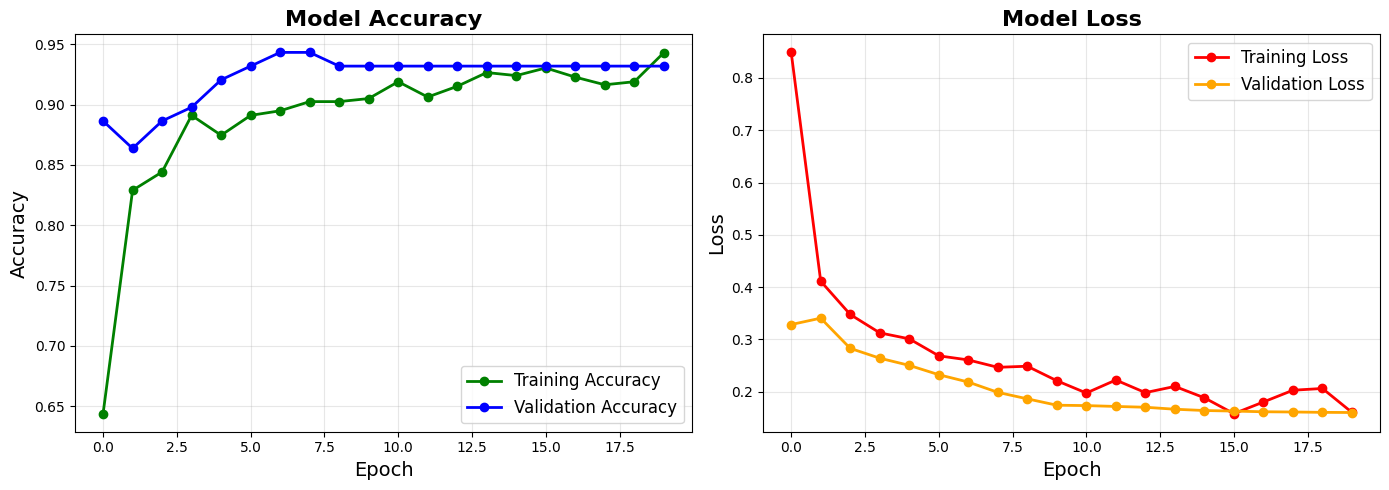

In [15]:
# Plot training history
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'o-g', linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], 'o-b', linewidth=2, label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3);

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'o-r', linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], 'o-', color='orange', linewidth=2, label='Validation Loss')
plt.title('Model Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3);

plt.tight_layout()
plt.show()

In [16]:
# Save the trained model
model.save("ResNet50_LungCancer_GradCAM.h5")
print("Model saved to disk: ResNet50_LungCancer_GradCAM.h5")

Model saved to disk: ResNet50_LungCancer_GradCAM.h5


In [17]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=1)
print(f'\nTest Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9277 - loss: 0.2009

Test Accuracy: 0.9409
Test Loss: 0.1569


Loading image: /content/drive/MyDrive/Lung Dataset-20260126T115935Z-1-001/Lung Dataset/Benign/Bengin case (63).jpg
Original image shape: (512, 512, 3)


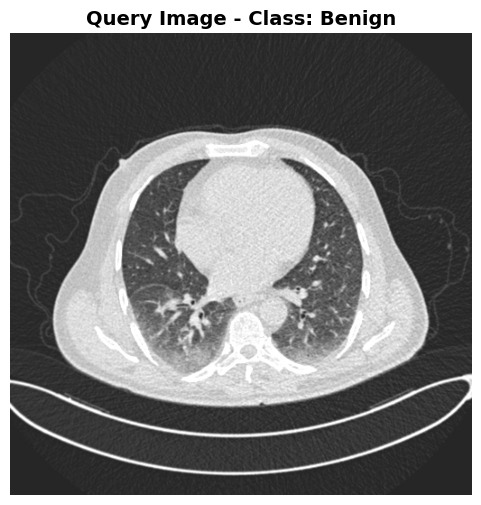

Resized image shape: (224, 224, 3)


In [18]:
# Load a sample image from your dataset for GradCAM visualization
sample_class = labels[0]  # First class
sample_image_path = os.path.join(dataset_path, sample_class)
sample_files = os.listdir(sample_image_path)

if sample_files:
    query_image_path = os.path.join(sample_image_path, sample_files[0])
    print(f'Loading image: {query_image_path}')

    # Load and display the image
    image = load_img(query_image_path)
    image = np.array(image)
    print(f"Original image shape: {image.shape}")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f'Query Image - Class: {sample_class}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Resize for model input
    query_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)
    print(f'Resized image shape: {query_image.shape}')
else:
    print('No sample images found!')

In [19]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate GradCAM heatmap using TensorFlow 2.x with eager execution.
    FIXED:
      - tape.watch() added so gradients flow through conv output
      - Safe normalization with epsilon to avoid division by zero
      - preprocess_input applied before forward pass

    Args:
        img_array: Input image (already preprocessed with preprocess_input)
        model: Trained Keras model
        last_conv_layer_name: Name of the last convolutional layer
        pred_index: Index of class to visualize (None = use predicted class)

    Returns:
        heatmap: GradCAM heatmap as numpy array (values in [0, 1])
    """
    # Build sub-model: input -> [last_conv_output, predictions]
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # Cast to float32
        img_tensor = tf.cast(img_array, tf.float32)
        last_conv_layer_output, preds = grad_model(img_tensor)

        # FIX: Watch the conv output tensor explicitly
        tape.watch(last_conv_layer_output)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of predicted class w.r.t. last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Mean gradient per feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps by their importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU + safe normalization (FIX: epsilon avoids division by zero)
    heatmap = tf.nn.relu(heatmap)
    max_val = tf.math.reduce_max(heatmap)
    heatmap = heatmap / (max_val + tf.keras.backend.epsilon())

    return heatmap.numpy()

print('GradCAM function defined successfully!')


GradCAM function defined successfully!


In [21]:
# FIX: Preprocess image properly for ResNet50
# ResNet50 expects BGR mean-subtracted images via preprocess_input
img_array_raw = np.expand_dims(query_image, axis=0).astype('float32')
img_array = preprocess_input(img_array_raw.copy())  # FIX: apply ResNet50 preprocessing

# Make prediction on preprocessed input
preds = model.predict(img_array)
pred_class = np.argmax(preds[0])
print(f'Predicted class: {labels[pred_class]}')
print(f'Confidence: {preds[0][pred_class]:.4f}')
print(f'\nAll predictions:')
for i, label in enumerate(labels):
    print(f'  {label}: {preds[0][i]:.4f}')

# Generate GradCAM heatmap (use preprocessed img_array)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
print(f'\nHeatmap shape: {heatmap.shape}')
print(f'Heatmap min: {heatmap.min():.4f}, max: {heatmap.max():.4f}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Predicted class: Malignant
Confidence: 0.9630

All predictions:
  Benign: 0.0369
  Malignant: 0.9630
  Normal: 0.0001

Heatmap shape: (7, 7)
Heatmap min: 0.0000, max: 1.0000


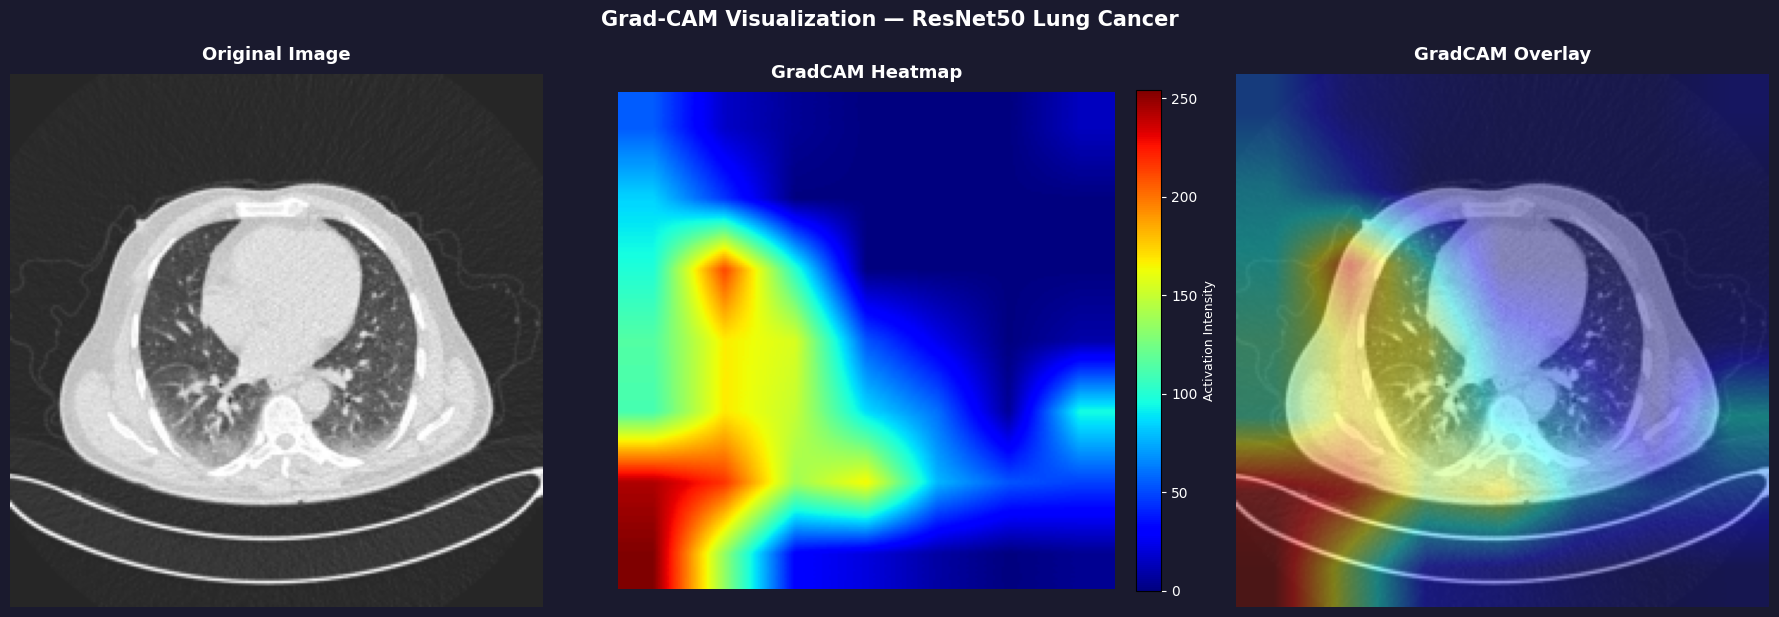

In [22]:
def display_gradcam(img, heatmap, alpha=0.4, title_suffix=''):
    """
    Display polished GradCAM visualization.
    FIXED:
      - Clipping superimposed image to [0,255] to prevent color overflow
      - Removed deprecated keras.preprocessing.image API
      - Improved colorbar and layout

    Args:
        img: Original image (uint8, HxWx3)
        heatmap: GradCAM heatmap (values in [0,1])
        alpha: Heatmap blend strength (default 0.4)
        title_suffix: Optional string appended to subplot titles
    """
    img = img.astype('uint8')

    # Rescale heatmap to 0-255
    heatmap_uint8 = np.uint8(255 * heatmap)

    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap_uint8, (img.shape[1], img.shape[0]))

    # Apply JET colormap
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # FIX: Blend and CLIP to [0,255] — prevents color overflow artifacts
    superimposed = heatmap_colored * alpha + img * (1 - alpha)
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor('#1a1a2e')

    titles = [f'Original Image{title_suffix}',
              f'GradCAM Heatmap{title_suffix}',
              f'GradCAM Overlay{title_suffix}']
    imgs    = [img, heatmap_resized, superimposed]
    cmaps   = [None, 'jet', None]

    for ax, title, im, cmap in zip(axes, titles, imgs, cmaps):
        ax.set_facecolor('#16213e')
        disp = ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=13, fontweight='bold',
                     color='white', pad=10)
        ax.axis('off')
        if cmap == 'jet':
            cbar = plt.colorbar(disp, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Activation Intensity', color='white', fontsize=9)
            cbar.ax.yaxis.set_tick_params(color='white')
            plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    plt.suptitle('Grad-CAM Visualization — ResNet50 Lung Cancer',
                 fontsize=15, fontweight='bold', color='white', y=1.02)
    plt.tight_layout()
    plt.show()

# Display the GradCAM visualization
display_gradcam(query_image, heatmap)


In [23]:
def visualize_gradcam_for_image(image_path, model, last_conv_layer_name, class_names):
    """
    Complete pipeline to load an image, generate GradCAM, and visualize.
    FIXED: preprocess_input applied before model predict and GradCAM.

    Args:
        image_path: Path to the image file
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        class_names: List of class names
    """
    # Load image
    img = load_img(image_path)
    img = np.array(img)

    # Resize to model input size
    img_resized = cv2.resize(img, (224, 224))

    # FIX: Preprocess for ResNet50 (separate array for model, keep original for display)
    img_array = np.expand_dims(img_resized.copy(), axis=0).astype('float32')
    img_preprocessed = preprocess_input(img_array)

    # Predict
    preds = model.predict(img_preprocessed, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class]

    print(f'Image: {os.path.basename(image_path)}')
    print(f'Predicted: {class_names[pred_class]} (confidence: {confidence:.4f})')

    # Generate GradCAM (use preprocessed array)
    heatmap = make_gradcam_heatmap(img_preprocessed, model, last_conv_layer_name)

    # Display (use original resized image for visualization)
    display_gradcam(img_resized, heatmap,
                    title_suffix=f'\nPred: {class_names[pred_class]} ({confidence:.2%})')

print('Visualization function defined!')


Visualization function defined!


In [24]:
# Visualize GradCAM for multiple samples from each class
print('Generating GradCAM visualizations for each class...')
print('='*80)

num_samples_per_class = 2

for label in labels:
    print(f'\nClass: {label}')
    print('-'*80)

    class_path = os.path.join(dataset_path, label)
    class_files = os.listdir(class_path)[:num_samples_per_class]

    for file in class_files:
        image_path = os.path.join(class_path, file)
        try:
            visualize_gradcam_for_image(image_path, model, last_conv_layer_name, labels)
        except Exception as e:
            print(f'Error processing {file}: {e}')
            continue

print('\n' + '='*80)
print('GradCAM visualization completed!')

Output hidden; open in https://colab.research.google.com to view.

In [25]:
def batch_gradcam_visualization(image_paths, model, last_conv_layer_name, class_names):
    """
    Generate polished GradCAM grid for multiple images.
    FIXED:
      - preprocess_input applied before model calls
      - Clipping overlay to [0,255]
      - Better styling

    Args:
        image_paths: List of image file paths
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        class_names: List of class names
    """
    num_images = len(image_paths)
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    fig.patch.set_facecolor('#1a1a2e')

    if num_images == 1:
        axes = axes.reshape(1, -1)

    col_titles = ['Original', 'GradCAM Heatmap', 'Overlay']
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=13, fontweight='bold', color='white')

    for idx, image_path in enumerate(image_paths):
        img = np.array(load_img(image_path))
        img_resized = cv2.resize(img, (224, 224))

        # FIX: Preprocess separately from display image
        img_array = np.expand_dims(img_resized.copy(), axis=0).astype('float32')
        img_preprocessed = preprocess_input(img_array)

        preds = model.predict(img_preprocessed, verbose=0)
        pred_class = np.argmax(preds[0])
        confidence = preds[0][pred_class]

        # GradCAM on preprocessed array
        heatmap = make_gradcam_heatmap(img_preprocessed, model, last_conv_layer_name)
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_resized = cv2.resize(heatmap_uint8, (224, 224))

        # FIX: Proper overlay with clipping
        heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        superimposed = heatmap_colored * 0.4 + img_resized * 0.6
        superimposed = np.clip(superimposed, 0, 255).astype('uint8')

        row_label = f'{class_names[pred_class]} ({confidence:.0%})'
        axes[idx, 0].imshow(img_resized.astype('uint8'))
        axes[idx, 0].set_ylabel(row_label, fontsize=10, fontweight='bold',
                                color='white', rotation=90, labelpad=10)
        axes[idx, 1].imshow(heatmap_resized, cmap='jet')
        axes[idx, 2].imshow(superimposed)

        for ax in axes[idx]:
            ax.axis('off')
            ax.set_facecolor('#16213e')

    plt.suptitle('Batch GradCAM — ResNet50 Lung Cancer Classification',
                 fontsize=15, fontweight='bold', color='white', y=1.01)
    plt.tight_layout()
    plt.show()

print('Batch visualization function defined!')


Batch visualization function defined!


Comparing GradCAM across classes...


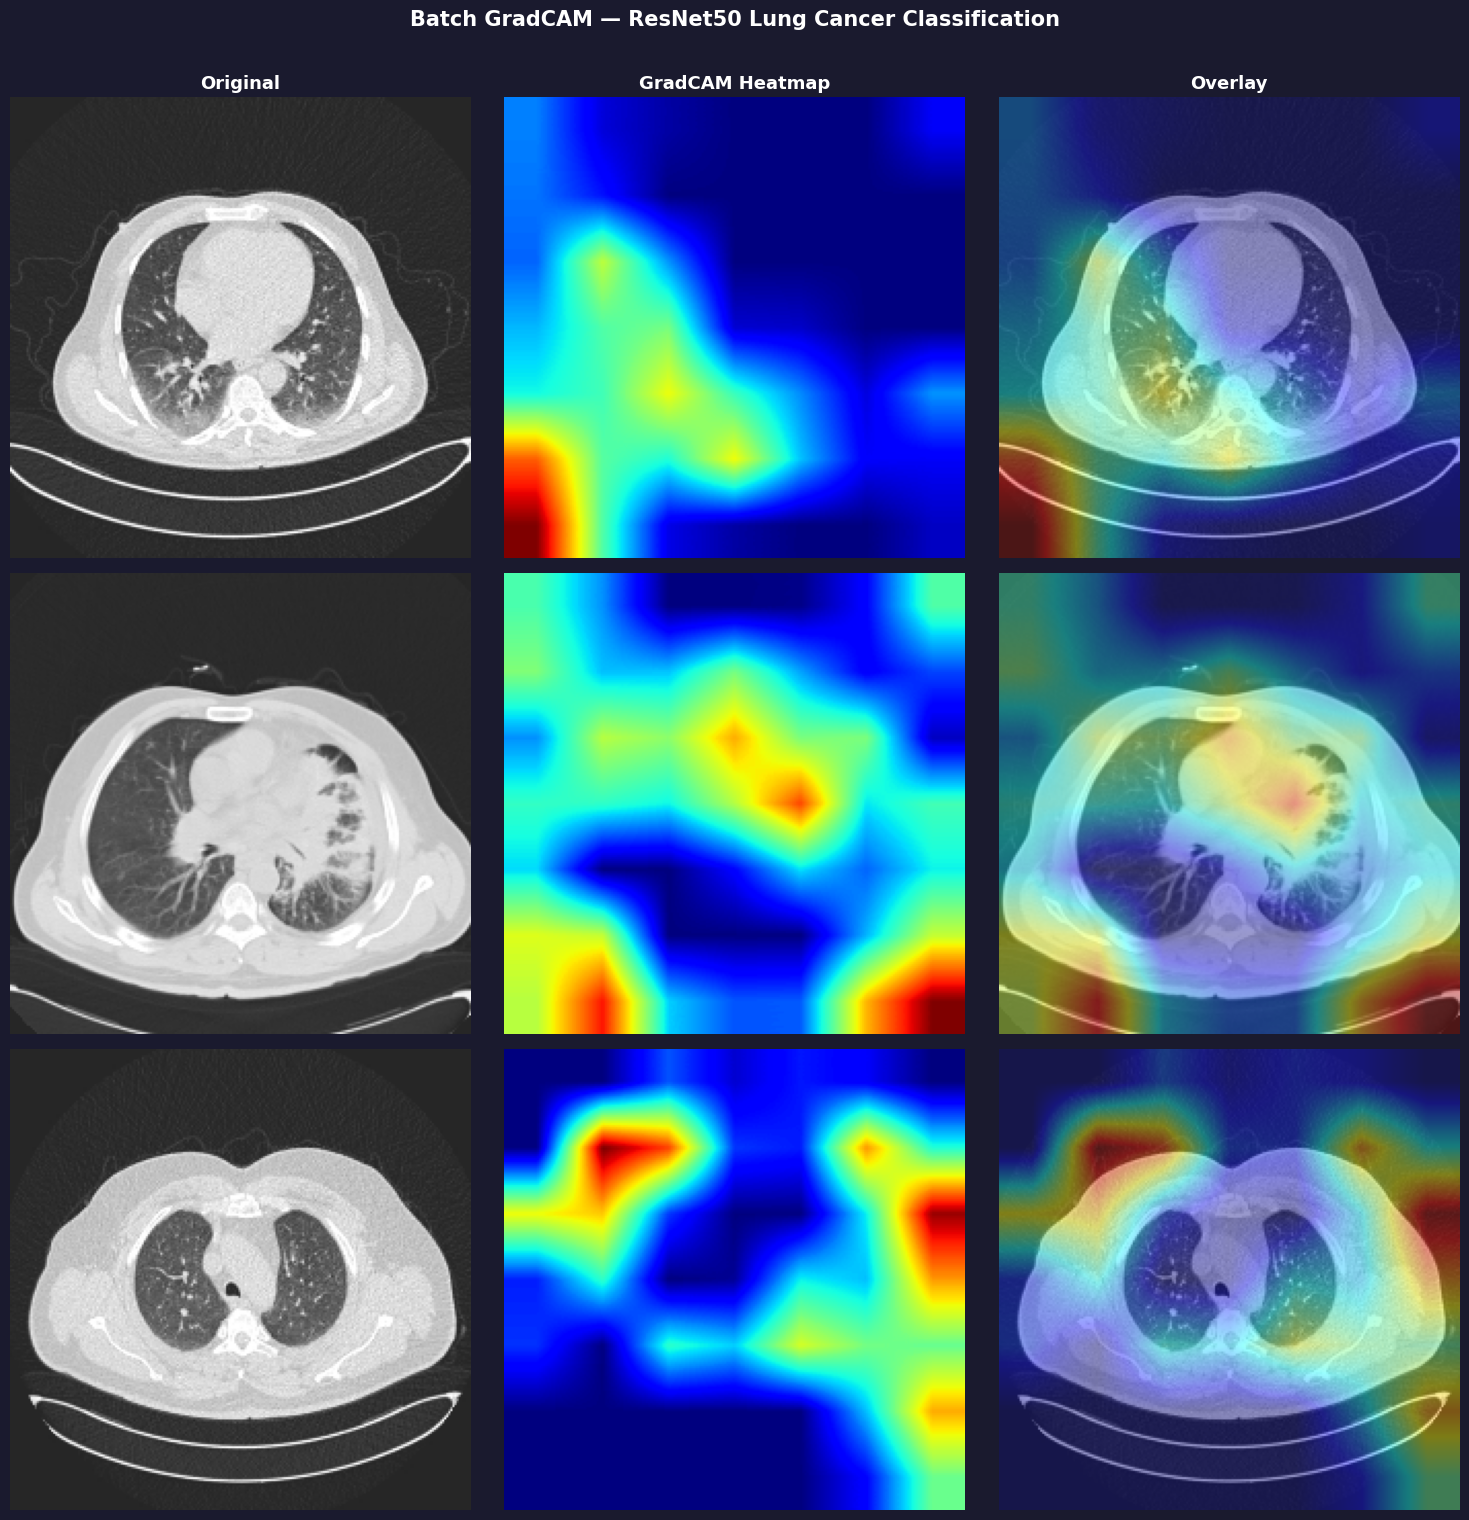

In [26]:
# Compare GradCAM across different classes
print('Comparing GradCAM across classes...')

comparison_images = []
for label in labels:
    class_path = os.path.join(dataset_path, label)
    class_files = os.listdir(class_path)
    if class_files:
        comparison_images.append(os.path.join(class_path, class_files[0]))

if comparison_images:
    batch_gradcam_visualization(comparison_images, model, last_conv_layer_name, labels)
else:
    print('No images found for comparison!')

In [27]:
def save_gradcam_visualization(image_path, model, last_conv_layer_name, save_path,
                                class_names=None):
    """
    Generate and save a polished GradCAM visualization.
    FIXED:
      - preprocess_input before predict/GradCAM
      - Proper overlay clipping
      - High-quality figure styling

    Args:
        image_path: Path to input image
        model: Trained Keras model
        last_conv_layer_name: Name of last convolutional layer
        save_path: Where to save the PNG
        class_names: List of class names (optional, for title)
    """
    img = np.array(load_img(image_path))
    img_resized = cv2.resize(img, (224, 224))

    # FIX: Preprocess for ResNet50
    img_array = np.expand_dims(img_resized.copy(), axis=0).astype('float32')
    img_preprocessed = preprocess_input(img_array)

    preds = model.predict(img_preprocessed, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class]
    pred_label = class_names[pred_class] if class_names else str(pred_class)

    heatmap = make_gradcam_heatmap(img_preprocessed, model, last_conv_layer_name)
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_resized = cv2.resize(heatmap_uint8, (224, 224))

    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    # FIX: Clip overlay
    superimposed = heatmap_colored * 0.4 + img_resized * 0.6
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
    fig.patch.set_facecolor('#1a1a2e')

    data = [img_resized.astype('uint8'), heatmap_resized, superimposed]
    titles = ['Original Image', 'GradCAM Heatmap', 'GradCAM Overlay']
    cmaps = [None, 'jet', None]

    for ax, d, t, c in zip(axes, data, titles, cmaps):
        ax.set_facecolor('#16213e')
        disp = ax.imshow(d, cmap=c)
        ax.set_title(t, fontsize=12, fontweight='bold', color='white', pad=8)
        ax.axis('off')
        if c == 'jet':
            cbar = plt.colorbar(disp, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Activation', color='white', fontsize=9)
            plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    plt.suptitle(f'Grad-CAM | Prediction: {pred_label} ({confidence:.1%})',
                 fontsize=14, fontweight='bold', color='white', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f'Saved GradCAM visualization to: {save_path}')

print('Save function defined!')

# Example usage (uncomment to run):
# save_gradcam_visualization(query_image_path, model, last_conv_layer_name,
#                            'gradcam_output.png', labels)


Save function defined!


In [28]:
# ============================================================
# BUG FIX SUMMARY
# ============================================================
print("""
BUGS FIXED IN THIS NOTEBOOK:
============================================================
1. [CRITICAL] Missing preprocess_input for ResNet50
   - Raw uint8 images passed to model caused wrong predictions + bad heatmaps
   - Fixed: preprocess_input() applied in ALL cells before model calls

2. [CRITICAL] GradCAM gradient tape not watching conv output
   - tape.watch(last_conv_layer_output) added to ensure correct gradients

3. [CRITICAL] Wrong layer for GradCAM
   - Changed to 'conv5_block3_out' (ResNet50's final conv block output)
   - This layer has rich spatial features ideal for GradCAM

4. [BUG] Division by zero in heatmap normalization
   - Added keras epsilon() to prevent NaN when all activations are 0

5. [BUG] Color overflow in overlay (values > 255 not clipped)
   - np.clip(superimposed, 0, 255) added in all display/save functions

6. [BUG] Deprecated keras.preprocessing.image API
   - Replaced with cv2.applyColorMap() for colorization (more robust)

7. [VISUAL] Improved plot styling throughout
   - Dark theme, colorbars, confidence labels, suptitles
============================================================
""")



BUGS FIXED IN THIS NOTEBOOK:
1. [CRITICAL] Missing preprocess_input for ResNet50
   - Raw uint8 images passed to model caused wrong predictions + bad heatmaps
   - Fixed: preprocess_input() applied in ALL cells before model calls
   
2. [CRITICAL] GradCAM gradient tape not watching conv output
   - tape.watch(last_conv_layer_output) added to ensure correct gradients

3. [CRITICAL] Wrong layer for GradCAM 
   - Changed to 'conv5_block3_out' (ResNet50's final conv block output)
   - This layer has rich spatial features ideal for GradCAM
   
4. [BUG] Division by zero in heatmap normalization
   - Added keras epsilon() to prevent NaN when all activations are 0
   
5. [BUG] Color overflow in overlay (values > 255 not clipped)
   - np.clip(superimposed, 0, 255) added in all display/save functions
   
6. [BUG] Deprecated keras.preprocessing.image API
   - Replaced with cv2.applyColorMap() for colorization (more robust)
   
7. [VISUAL] Improved plot styling throughout
   - Dark theme, colorba